# Fraud Detection Dataset – Exploratory Data Analysis, Anomaly detection and fraud prediction

In this notebook, we explore a large credit card transaction dataset containing over 1.2 million (1,296,675) transactions, of which roughly 7,506 are labeled as fraud. The goal is to understand key behavioral patterns, regional fraud distributions, time-based trends and transaction-level characteristics that can inform future modeling efforts.

Our EDA is structured around several core questions:

* Where is fraud happening most often (by state, city and merchant)
  
* When does fraud tend to occur — are there patterns across time, such as specific hours, days, or months

  
* Which categories and users are most associated with fraud

  
* Do fraudulent transactions differ in amount or distance compared to legitimate ones

  
* Can we visually spot anomalies or concentration zones using heatmaps and distribution plots?


The insights below were extracted using descriptive statistics, group-wise aggregations and intuitive visualizations. They lay the foundation for the next phase: predictive modeling and anomaly detection.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

'''
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
'''
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

"\nimport os\nfor dirname, _, filenames in os.walk('/kaggle/input'):\n    for filename in filenames:\n        print(os.path.join(dirname, filename))\n"

### Import Libraries

In [2]:
#!pip install folium

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import folium
from folium.plugins import HeatMap


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [4]:
train_df = pd.read_csv(r'fraudTrain.csv')
test_df = pd.read_csv(r'fraudTest.csv')

train_df = train_df.drop('Unnamed: 0', axis=1)
test_df = test_df.drop('Unnamed: 0', axis=1)

train_df


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0


In [5]:
test_df

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,Luray,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


### Stats of numerical columns

In [6]:
train_df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [7]:
train_df.trans_date_trans_time = pd.to_datetime(train_df.trans_date_trans_time)
test_df.trans_date_trans_time = pd.to_datetime(test_df.trans_date_trans_time)



len(train_df.cc_num.unique()) #983


983

In [8]:
len(test_df.cc_num.unique()) #924

924

## With a data of around 1.3m transactions, there are 983 unique credit card users.
### Additionally, we also calculate transaction distance between user and merchant

In [9]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

train_df['txn_distance_km'] = haversine(train_df['lat'], train_df['long'], train_df['merch_lat'], train_df['merch_long'])
train_df['txn_distance_mi'] = train_df['txn_distance_km']* 0.621371

test_df['txn_distance_km'] = haversine(test_df['lat'], test_df['long'], test_df['merch_lat'], test_df['merch_long'])
test_df['txn_distance_mi'] = test_df['txn_distance_km']* 0.621371

df_fraud = train_df[train_df.is_fraud==1] # training data
test_df_fraud = test_df[test_df.is_fraud==1] # test data

train_df

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,txn_distance_km,txn_distance_mi
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,78.597568,48.838250
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,30.212176,18.772970
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,108.206083,67.236122
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,95.673231,59.448571
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,77.556744,48.191511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,...,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,119.752136,74.410505
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,...,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,75.104085,46.667501
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,...,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,99.047734,61.545389
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,...,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,84.627652,52.585169


In [10]:
test_df

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,txn_distance_km,txn_distance_mi
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,24.561462,15.261780
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,104.925092,65.197409
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,59.080078,36.710647
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,27.698567,17.211086
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,104.335106,64.830809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,Luray,...,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0,77.026148,47.861814
555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,...,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0,100.074420,62.183342
555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,...,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0,80.759302,50.181488
555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,...,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0,52.933240,32.891181


In [11]:
df_fraud

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,txn_distance_km,txn_distance_mi
2449,2019-01-02 01:06:37,4613314721966,fraud_Rutherford-Mertz,grocery_pos,281.06,Jason,Murphy,M,542 Steve Curve Suite 011,Collettsville,...,885,Soil scientist,1988-09-15,e8a81877ae9a0a7f883e15cb39dc4022,1325466397,36.430124,-81.179483,1,68.953442,42.845669
2472,2019-01-02 01:47:29,340187018810220,"fraud_Jenkins, Hauck and Friesen",gas_transport,11.52,Misty,Hart,F,27954 Hall Mill Suite 575,San Antonio,...,1595797,Horticultural consultant,1960-10-28,bc7d41c41103877b03232f03f1f8d3f5,1325468849,29.819364,-99.142791,1,78.406096,48.719274
2523,2019-01-02 03:05:23,340187018810220,fraud_Goodwin-Nitzsche,grocery_pos,276.31,Misty,Hart,F,27954 Hall Mill Suite 575,San Antonio,...,1595797,Horticultural consultant,1960-10-28,b98f12f4168391b2203238813df5aa8c,1325473523,29.273085,-98.836360,1,41.012191,25.483786
2546,2019-01-02 03:38:03,4613314721966,fraud_Erdman-Kertzmann,gas_transport,7.03,Jason,Murphy,M,542 Steve Curve Suite 011,Collettsville,...,885,Soil scientist,1988-09-15,397894a5c4c02e3c61c784001f0f14e4,1325475483,35.909292,-82.091010,1,34.145794,21.217206
2553,2019-01-02 03:55:47,340187018810220,fraud_Koepp-Parker,grocery_pos,275.73,Misty,Hart,F,27954 Hall Mill Suite 575,San Antonio,...,1595797,Horticultural consultant,1960-10-28,7863235a750d73a244c07f1fb7f0185a,1325476547,29.786426,-98.683410,1,44.209442,27.470465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295399,2020-06-21 01:00:08,3524574586339330,fraud_Kassulke PLC,shopping_net,977.01,Ashley,Cabrera,F,94225 Smith Springs Apt. 617,Vero Beach,...,105638,"Librarian, public",1986-05-07,a83b093f0c1d9068fa0089f7c722615f,1371776408,26.888686,-80.834389,1,93.097732,57.848231
1295491,2020-06-21 01:53:35,3524574586339330,fraud_Schumm PLC,shopping_net,1210.91,Ashley,Cabrera,F,94225 Smith Springs Apt. 617,Vero Beach,...,105638,"Librarian, public",1986-05-07,f75b35bed13b9e692f170dba45a15b21,1371779615,28.216707,-79.855648,1,84.294502,52.378159
1295532,2020-06-21 02:16:56,4005676619255478,"fraud_Tillman, Dickinson and Labadie",gas_transport,10.24,William,Perry,M,458 Phillips Island Apt. 768,Denham Springs,...,71335,Herbalist,1994-05-31,a0ba2472cd3fc9731f2a18d3f308f5c3,1371781016,29.700456,-91.361632,1,95.206112,59.158317
1295666,2020-06-21 03:26:20,3560725013359375,fraud_Corwin-Collins,gas_transport,21.69,Brooke,Smith,F,63542 Luna Brook Apt. 012,Notrees,...,23,Cytogeneticist,1969-09-15,daa281350b1e16093c7b4bf97bf4d6ed,1371785180,32.675272,-103.484949,1,114.493429,71.142896


In [12]:
train_df[train_df['state']=='DE']

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,txn_distance_km,txn_distance_mi
233631,2019-04-28 00:41:37,6011826317034777,fraud_Schamberger-O'Keefe,grocery_pos,294.91,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,...,18799,"Designer, multimedia",2000-03-16,8f85e701f609911b99bea627eb71aa49,1335573697,38.166715,-75.023367,1,65.443273,40.664552
233744,2019-04-28 01:49:28,6011826317034777,fraud_Kuphal-Predovic,misc_net,868.29,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,...,18799,"Designer, multimedia",2000-03-16,8c941f2849ccac44d32ef08ea784fc67,1335577768,38.910900,-74.856625,1,53.172813,33.040044
233826,2019-04-28 02:33:09,6011826317034777,fraud_Goodwin-Nitzsche,grocery_pos,280.26,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,...,18799,"Designer, multimedia",2000-03-16,0fc1109cb9a10961595e79736ccc1293,1335580389,38.523208,-74.460889,1,82.848548,51.479685
234625,2019-04-28 10:24:34,6011826317034777,"fraud_Huel, Hammes and Witting",grocery_pos,296.25,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,...,18799,"Designer, multimedia",2000-03-16,b4248cfc8b44fec6193767918d49b334,1335608674,38.593896,-76.031493,1,56.241904,34.947088
236522,2019-04-28 23:03:24,6011826317034777,fraud_Waters-Cruickshank,health_fitness,20.58,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,...,18799,"Designer, multimedia",2000-03-16,567ed9b2d7d10ad519cdd697cd338f70,1335654204,39.003922,-75.852152,1,53.715115,33.377015
236643,2019-04-28 23:41:43,6011826317034777,fraud_Cormier LLC,shopping_net,1012.77,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,...,18799,"Designer, multimedia",2000-03-16,00d158609d7ac753da792e9d0eb88a0b,1335656503,39.596186,-75.559281,1,102.987341,63.993347
237095,2019-04-29 03:29:41,6011826317034777,fraud_Ruecker Group,misc_net,885.96,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,...,18799,"Designer, multimedia",2000-03-16,e0613e4142b2d05867299832ac453e01,1335670181,39.666374,-76.358642,1,137.767111,85.604488
237740,2019-04-29 10:13:47,6011826317034777,fraud_Smitham-Schiller,grocery_net,10.93,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,...,18799,"Designer, multimedia",2000-03-16,788a8fea8199a4e8a6a47ffab824e571,1335694427,37.691598,-76.058416,1,124.236901,77.197207
239854,2019-04-29 23:51:22,6011826317034777,"fraud_Baumbach, Feeney and Morar",shopping_net,960.49,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,...,18799,"Designer, multimedia",2000-03-16,4193b953223a1c9432f9d3c380e67be9,1335743482,39.073319,-75.545153,1,45.776842,28.444402


## We can see that all of DE's transactions are fraud and they just have one Credit card user. Making this an outlier. These records will be removed in anomaly detection and ML building.

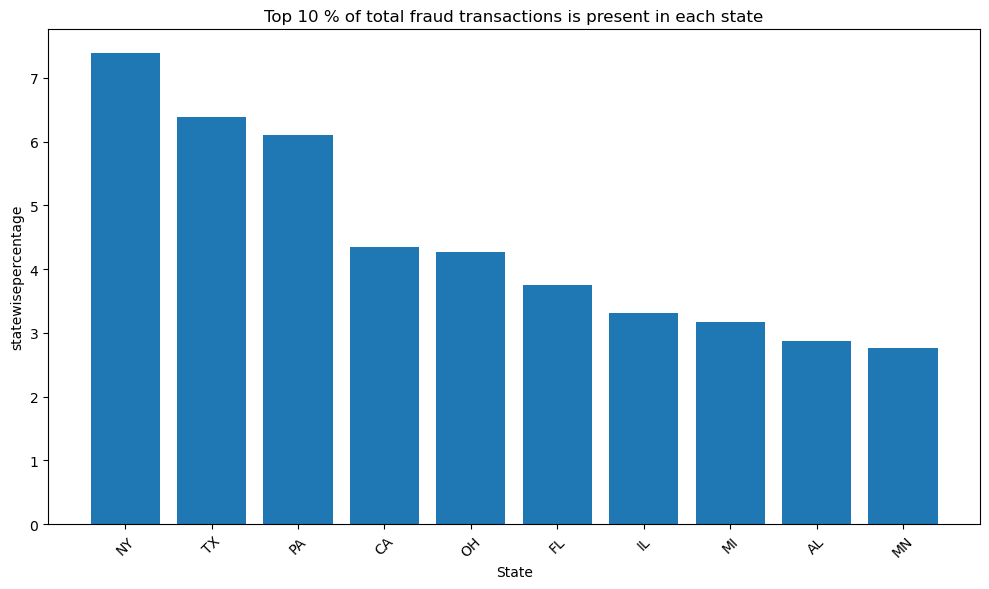

In [13]:
# how much % of total fraud transactions is present in each state
df_fraudper = (
    df_fraud['state']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
    .rename(columns={'index': 'state', 'state': 'statewisepercentage'})
)


top10 = df_fraudper.nlargest(10, 'statewisepercentage')
plt.figure(figsize=(10,6))
plt.bar(top10['state'], top10['statewisepercentage'])
plt.xlabel('State')
plt.ylabel('statewisepercentage')
plt.title('Top 10 % of total fraud transactions is present in each state')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

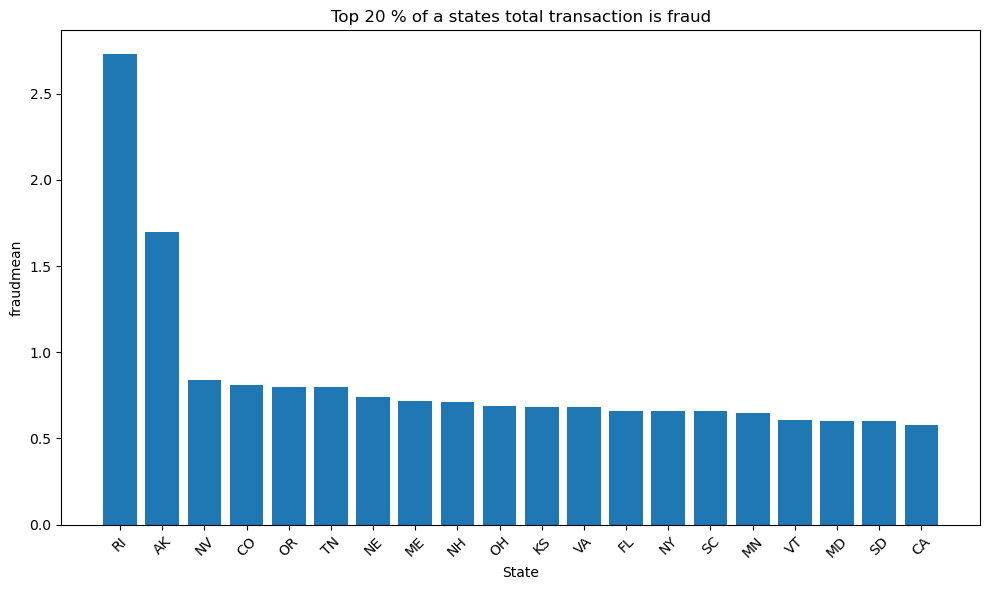

In [14]:
#how much % of a state's total transaction is fraud

dfgroup = train_df.groupby('state').apply(
    lambda x: round((x['is_fraud'] == 1).mean()*100, 2)
    ).reset_index(name='fraudmean')

dfgroup = dfgroup[dfgroup['state']!='DE']

top10 = dfgroup.nlargest(20, 'fraudmean')
plt.figure(figsize=(10,6))
plt.bar(top10['state'], top10['fraudmean'])
plt.xlabel('State')
plt.ylabel('fraudmean')
plt.title('Top 20 % of a states total transaction is fraud')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

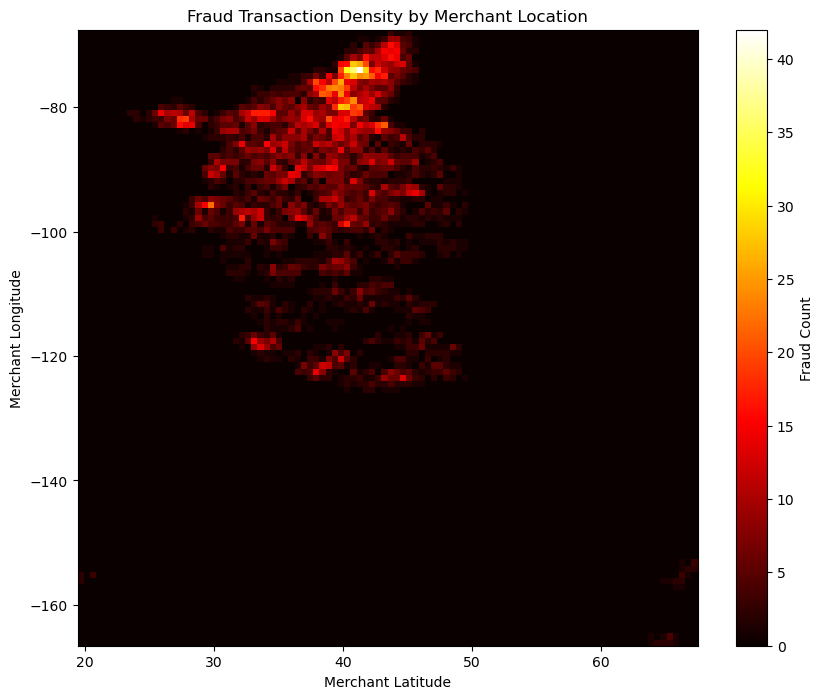

In [15]:
plt.figure(figsize=(10, 8))
plt.hist2d(df_fraud['merch_lat'], df_fraud['merch_long'], bins=100, cmap='hot')
plt.colorbar(label='Fraud Count')
plt.xlabel('Merchant Latitude')
plt.ylabel('Merchant Longitude')
plt.title('Fraud Transaction Density by Merchant Location')
plt.show()

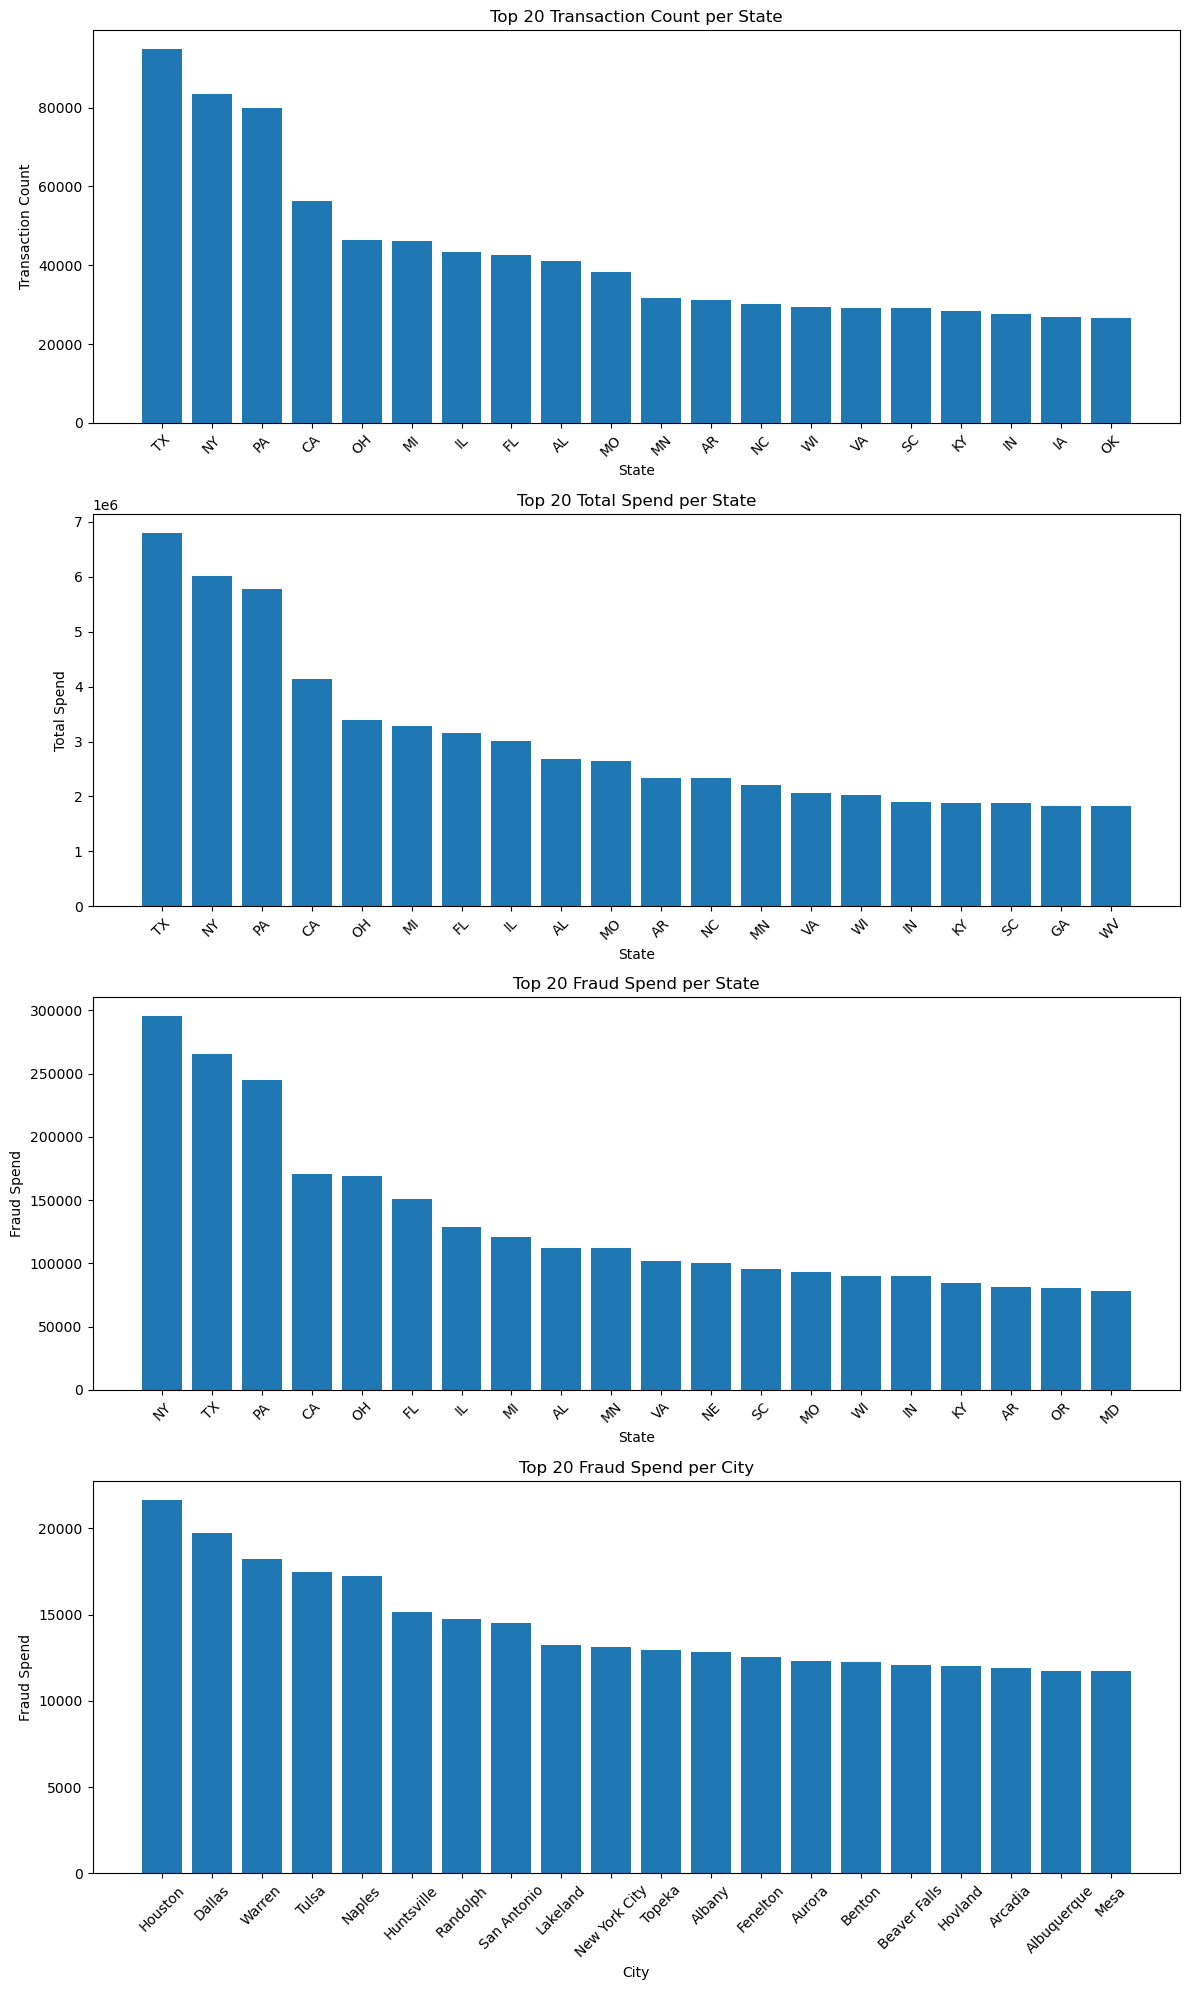

In [16]:
fig, axs = plt.subplots(4, 1, figsize=(12, 20))

# 1. Transaction count per state
dfcatspend = train_df.groupby('state').size().reset_index(name='categorycount')
top10_count = dfcatspend.nlargest(20, 'categorycount')
axs[0].bar(top10_count['state'], top10_count['categorycount'])
axs[0].set_title('Top 20 Transaction Count per State')
axs[0].set_xlabel('State')
axs[0].set_ylabel('Transaction Count')
axs[0].tick_params(axis='x', rotation=45)

# 2. Total transaction amount per state
dfcatamt = train_df.groupby('state')['amt'].sum().reset_index(name='categoryspend')
top10_total_spend = dfcatamt.nlargest(20, 'categoryspend')
axs[1].bar(top10_total_spend['state'], top10_total_spend['categoryspend'])
axs[1].set_title('Top 20 Total Spend per State')
axs[1].set_xlabel('State')
axs[1].set_ylabel('Total Spend')
axs[1].tick_params(axis='x', rotation=45)

# 3. Fraud transaction amount per state
dfcatamt_fraud_state = train_df[train_df['is_fraud'] == 1].groupby('state')['amt'].sum().reset_index(name='categoryspend')
top10_fraud_spend_state = dfcatamt_fraud_state.nlargest(20, 'categoryspend')
axs[2].bar(top10_fraud_spend_state['state'], top10_fraud_spend_state['categoryspend'])
axs[2].set_title('Top 20 Fraud Spend per State')
axs[2].set_xlabel('State')
axs[2].set_ylabel('Fraud Spend')
axs[2].tick_params(axis='x', rotation=45)

# 4. Fraud transaction amount per city
dfcatamt_fraud_city = train_df[train_df['is_fraud'] == 1].groupby('city')['amt'].sum().reset_index(name='categoryspend')
top10_fraud_spend_city = dfcatamt_fraud_city.nlargest(20, 'categoryspend')
axs[3].bar(top10_fraud_spend_city['city'], top10_fraud_spend_city['categoryspend'])
axs[3].set_title('Top 20 Fraud Spend per City')
axs[3].set_xlabel('City')
axs[3].set_ylabel('Fraud Spend')
axs[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Geographic Patterns in Fraud

### We began by analyzing how fraud is distributed across U.S. states and cities.

Some key observations:
* States like **NY, TX and PA** account for a high percentage of total fraud transactions.
  
* In contrast, when looking at fraud as a percentage of a state’s total transactions, states like **Rhode Island, Arkansas and Nevada** have unusually high fraud ratios — possibly outliers or low-volume states.

  
* At the city level, **Houston, Dallas and Warren** stand out as hotspots for fraud spending.

A fraud heatmap further confirms that urban and high-population regions experience the densest fraud activity.

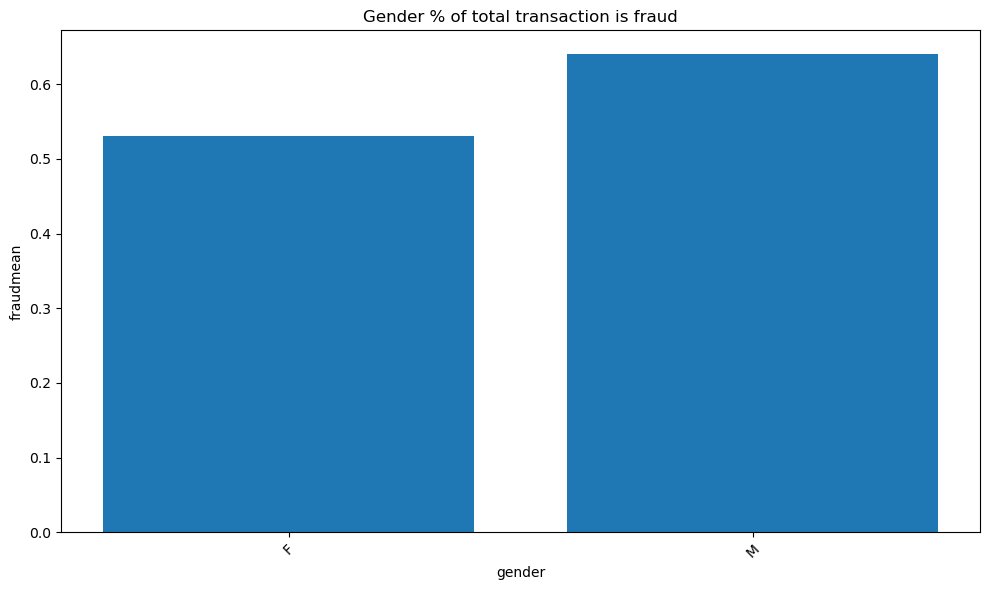

In [17]:
#how much % of a gender's total transaction is fraud
dfgendergroup = train_df.groupby('gender').apply(
    lambda x: round((x['is_fraud'] == 1).mean()*100, 2)
    ).reset_index(name='fraudmean')

# gender fraudmean
# F	    0.53
# M	    0.64


# top10 = dfgendergroup.nlargest(20, 'fraudmean')
plt.figure(figsize=(10,6))
plt.bar(dfgendergroup['gender'], dfgendergroup['fraudmean'])
plt.xlabel('gender')
plt.ylabel('fraudmean')
plt.title('Gender % of total transaction is fraud')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

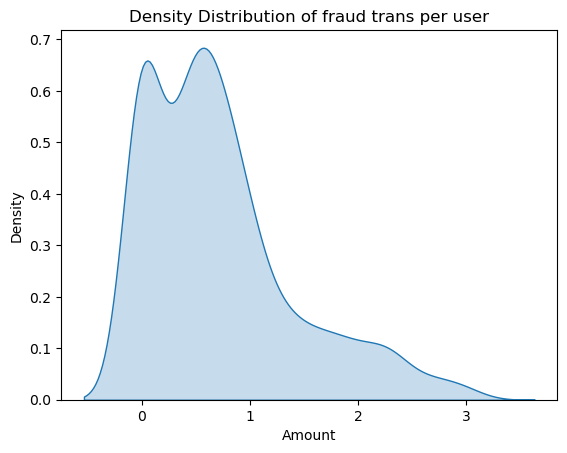

In [18]:
#how much % of a user's total transaction is fraud
dfusergroup = train_df.groupby('cc_num').apply(
    lambda x: round((x['is_fraud'] == 1).mean()*100, 2)
    ).reset_index(name='userfraudmean')

#7.6% of all credit card numbers are outliers
#They have all their transactions as fraud
dfuseroutliers = dfusergroup[dfusergroup['userfraudmean']>=80]

dfoutliers = train_df[train_df['cc_num'].isin(dfuseroutliers.cc_num)]

dfusergroup = dfusergroup[dfusergroup['userfraudmean']<80]

sns.kdeplot(dfusergroup['userfraudmean'], fill=True)
plt.title('Density Distribution of fraud trans per user')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.show()

E:\spark_temp\ipykernel_12416\2654821352.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fraud['dayofweek'] = df_fraud['trans_date_trans_time'].dt.strftime('%a')
E:\spark_temp\ipykernel_12416\2654821352.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fraud['dayofmonth'] = df_fraud['trans_date_trans_time'].dt.strftime('%d')
E:\spark_temp\ipykernel_12416\2654821352.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

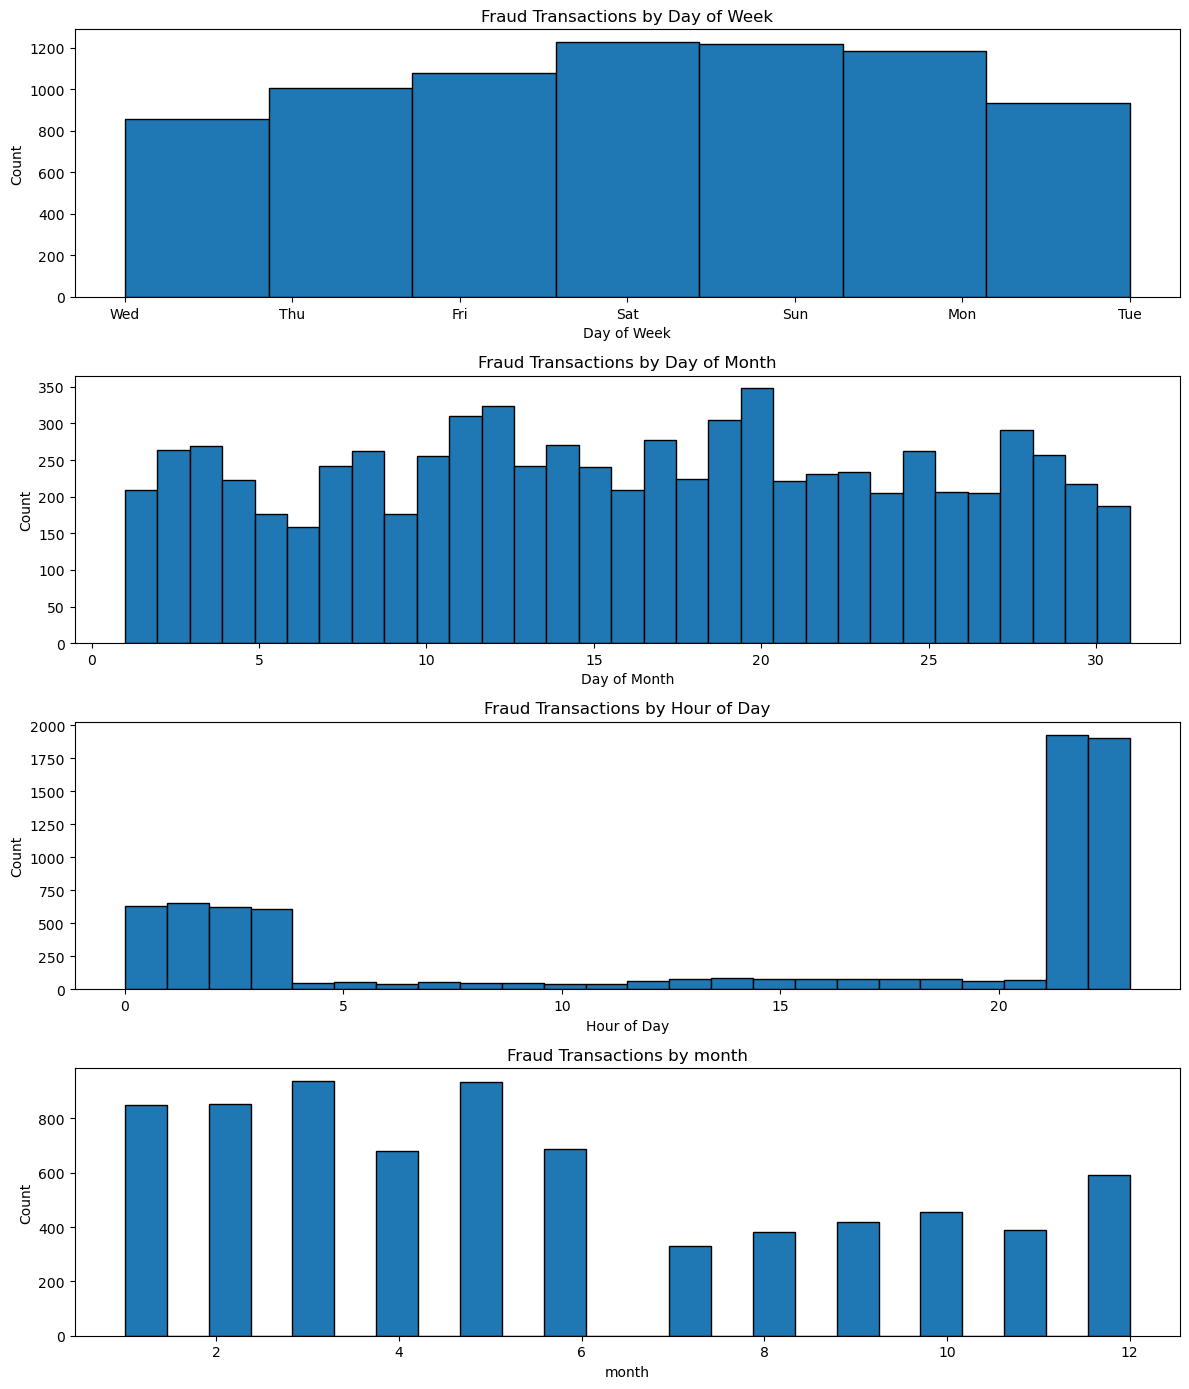

In [19]:
#time of day and day of week from training dataset for fraud
df_fraud['dayofweek'] = df_fraud['trans_date_trans_time'].dt.strftime('%a')
df_fraud['dayofmonth'] = df_fraud['trans_date_trans_time'].dt.strftime('%d')
df_fraud['timeofday'] = df_fraud['trans_date_trans_time'].dt.strftime('%H')
df_fraud['month'] = df_fraud['trans_date_trans_time'].dt.strftime('%m')

#time of day and day of week from test dataset for fraud
test_df_fraud['dayofweek'] = test_df_fraud['trans_date_trans_time'].dt.strftime('%a')
test_df_fraud['dayofmonth'] = test_df_fraud['trans_date_trans_time'].dt.strftime('%d')
test_df_fraud['timeofday'] = test_df_fraud['trans_date_trans_time'].dt.strftime('%H')
test_df_fraud['month'] = test_df_fraud['trans_date_trans_time'].dt.strftime('%m')


fig, axs = plt.subplots(4, 1, figsize=(12, 14))

# Day of week
axs[0].hist(df_fraud['dayofweek'], bins=7, edgecolor='black')
axs[0].set_title('Fraud Transactions by Day of Week')
axs[0].set_xlabel('Day of Week')
axs[0].set_ylabel('Count')

# Day of month
axs[1].hist(df_fraud['dayofmonth'].astype(int), bins=31, edgecolor='black')
axs[1].set_title('Fraud Transactions by Day of Month')
axs[1].set_xlabel('Day of Month')
axs[1].set_ylabel('Count')

# Hour of day
axs[2].hist(df_fraud['timeofday'].astype(int), bins=24, edgecolor='black')
axs[2].set_title('Fraud Transactions by Hour of Day')
axs[2].set_xlabel('Hour of Day')
axs[2].set_ylabel('Count')

# month
axs[3].hist(df_fraud['month'].astype(int), bins=24, edgecolor='black')
axs[3].set_title('Fraud Transactions by month')
axs[3].set_xlabel('month')
axs[3].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Temporal Trends in Fraud

### We explored how fraud varies by time features like day of week, day of month, hour of day and month.

* Fraud activity tends to spike during **Sat, Sun and Mon**.
  
* A notable volume of fraud occurs late at night, especially between **10 PM and 4 AM**, suggesting attackers exploit off-peak hours.

  
* Across the calendar, **begining months** exhibit higher fraud volumes — potentially aligning with shopping seasons or end-of-quarter behaviors.

Interestingly, day-of-month trends appeared more scattered and less predictive.

# EDA on total spending trends

### CategoryGroup

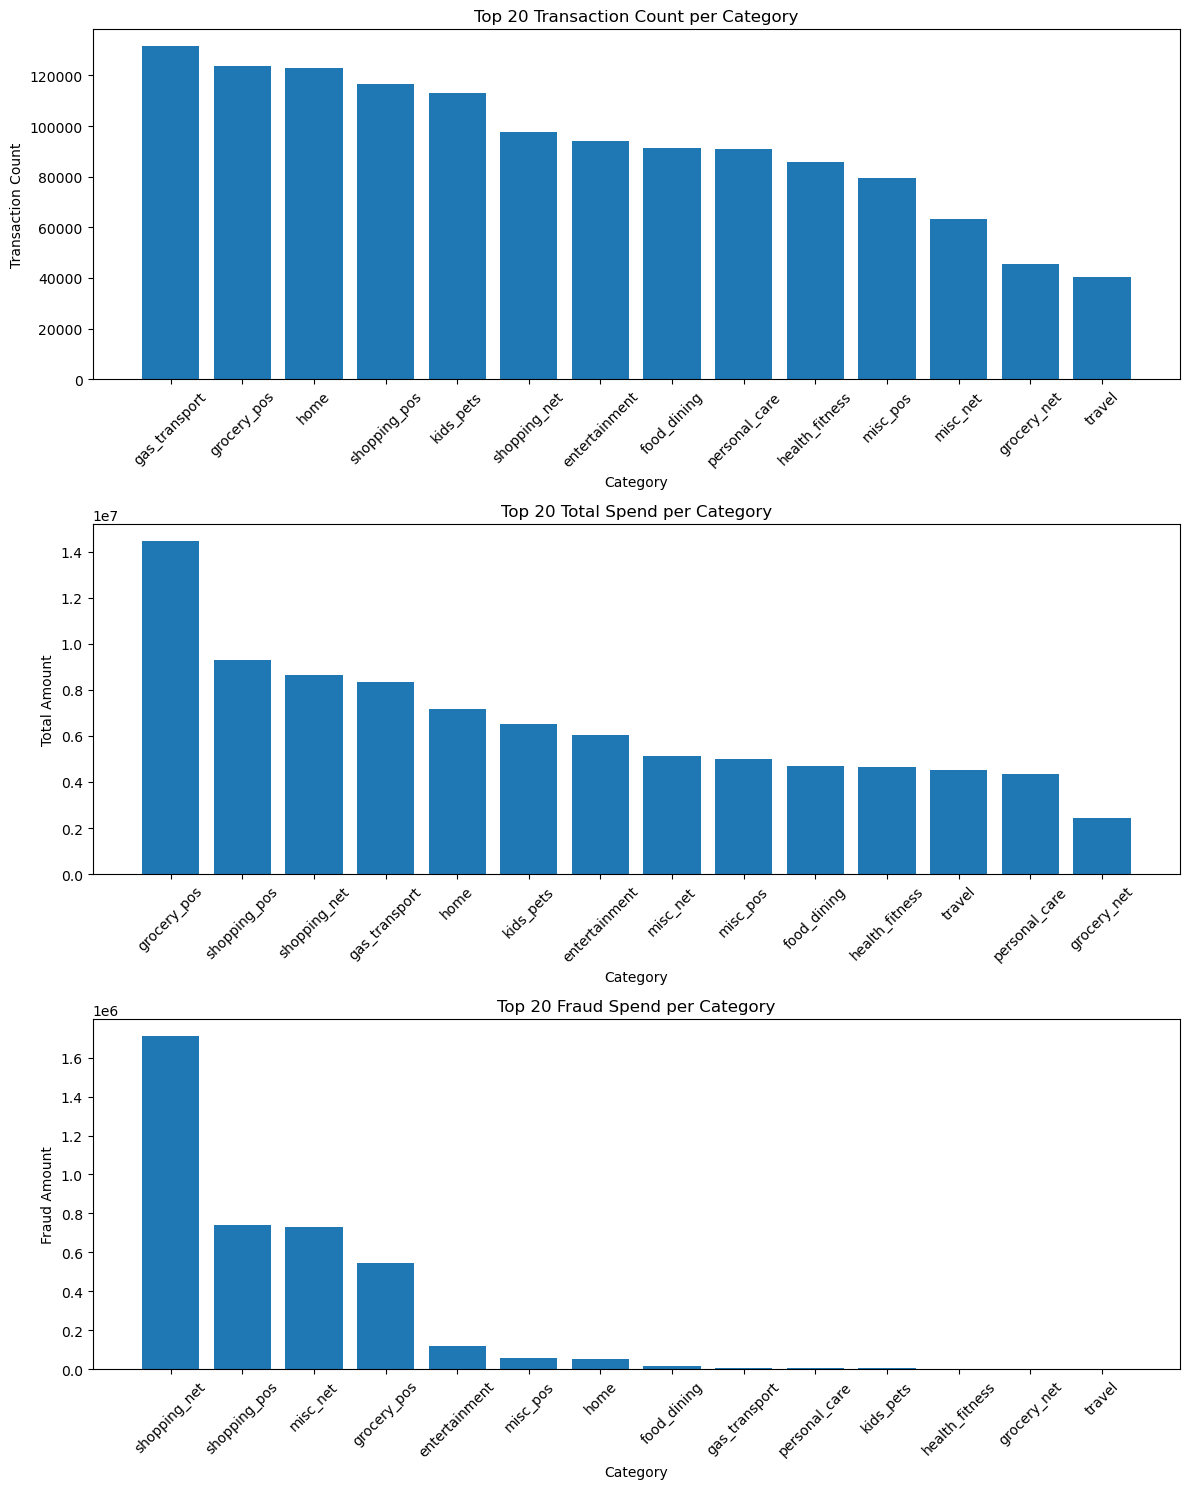

In [20]:
fig, axs = plt.subplots(3, 1, figsize=(12, 15))

# 1. Transaction count per category
dfcatspend = train_df.groupby('category').size().reset_index(name='categorycount')
top10_count = dfcatspend.nlargest(20, 'categorycount')
axs[0].bar(top10_count['category'], top10_count['categorycount'])
axs[0].set_title('Top 20 Transaction Count per Category')
axs[0].set_xlabel('Category')
axs[0].set_ylabel('Transaction Count')
axs[0].tick_params(axis='x', rotation=45)

# 2. Total amount spent per category
dfcatamt = train_df.groupby('category')['amt'].sum().reset_index(name='categoryspend')
top10_total_spend = dfcatamt.nlargest(20, 'categoryspend')
axs[1].bar(top10_total_spend['category'], top10_total_spend['categoryspend'])
axs[1].set_title('Top 20 Total Spend per Category')
axs[1].set_xlabel('Category')
axs[1].set_ylabel('Total Amount')
axs[1].tick_params(axis='x', rotation=45)

# 3. Fraud amount spent per category
dfcatamt_fraud = train_df[train_df['is_fraud'] == 1].groupby('category')['amt'].sum().reset_index(name='categoryspend')
top10_fraud_spend = dfcatamt_fraud.nlargest(20, 'categoryspend')
axs[2].bar(top10_fraud_spend['category'], top10_fraud_spend['categoryspend'])
axs[2].set_title('Top 20 Fraud Spend per Category')
axs[2].set_xlabel('Category')
axs[2].set_ylabel('Fraud Amount')
axs[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Category-Based Fraud Insights

### We examined transaction count and total spending across merchant categories:
* Categories like Gas, Grocery and Home have the highest transaction volumes overall and categories like grocery and shopping have the highest transaction amounts.
  
* However, fraud is concentrated in different categories — notably shopping, where a large percentage of transactions are fraudulent.

  
* This discrepancy suggests that some categories are more prone to fraud despite low overall usage.

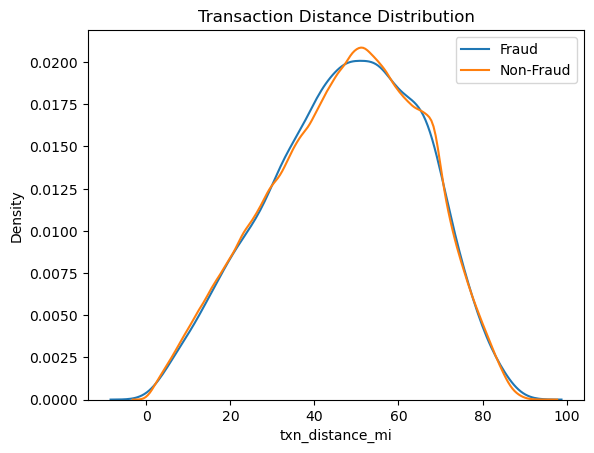

In [21]:
sns.kdeplot(train_df[train_df['is_fraud']==1]['txn_distance_mi'], label='Fraud')
sns.kdeplot(train_df[train_df['is_fraud']==0]['txn_distance_mi'], label='Non-Fraud')
plt.legend()
plt.title('Transaction Distance Distribution')
plt.show()

# Transaction Behavior and Distance

### By calculating the distance between the user and merchant for each transaction:

* We observed that fraudulent and non-fraudulent transactions have nearly identical distance distributions, indicating distance alone isn’t a strong fraud predictor.
  
* Most transactions — both legit and fraudulent — occur within 40 to 60 miles.

In [22]:
import folium
from folium.plugins import HeatMap, MarkerCluster

# Center map on fraud coordinates
map_center = [df_fraud['merch_lat'].mean(), df_fraud['merch_long'].mean()]
m = folium.Map(location=map_center, zoom_start=5, tiles='CartoDB dark_matter')

# Add HeatMap
heat_data = df_fraud[['merch_lat', 'merch_long']].values.tolist()
HeatMap(heat_data, radius=8, blur=12, max_zoom=13).add_to(m)

# Optional: Add clustered fraud merchant markers
marker_cluster = MarkerCluster().add_to(m)
for _, row in df_fraud.iterrows():
    popup_text = f"Merchant: {row['merchant']}<br>City: {row['city']}<br>Amount: ${row['amt']:.2f}"
    folium.Marker(
        location=[row['merch_lat'], row['merch_long']],
        popup=popup_text,
        icon=folium.Icon(color='red', icon='exclamation-triangle', prefix='fa')
    ).add_to(marker_cluster)

# Add title (using FloatImage as hack)
title_html = '''
     <h3 align="center" style="font-size:16px"><b>Fraud Transaction Hotspots</b></h3>
     '''
m.get_root().html.add_child(folium.Element(title_html))

# Save
m.save('fraud_heatmap_enhanced.html')

In [23]:
# Center map at average fraud location
map_center = [df_fraud['merch_lat'].mean(), df_fraud['merch_long'].mean()]
m = folium.Map(location=map_center, zoom_start=5)

# Add heatmap
heat_data = df_fraud[['merch_lat', 'merch_long']].values.tolist()
HeatMap(heat_data, radius=8).add_to(m)

m.save("fraud_heatmap.html")

# User-Level Clustering for Fraud Pattern Discovery

This section explores clustering users based on their transaction behaviors, risk exposure and fraud profiles. We engineer behavioral and time-series features, normalize the dataset and apply KMeans clustering to identify segments of users with similar characteristics.

## Time-Series Feature Engineering

We begin by computing 7-day and 30-day rolling average transaction amounts per user (cc_num). This captures short-term and long-term spending behavior, which can help differentiate consistent spenders from those with volatile or bursty spending patterns.

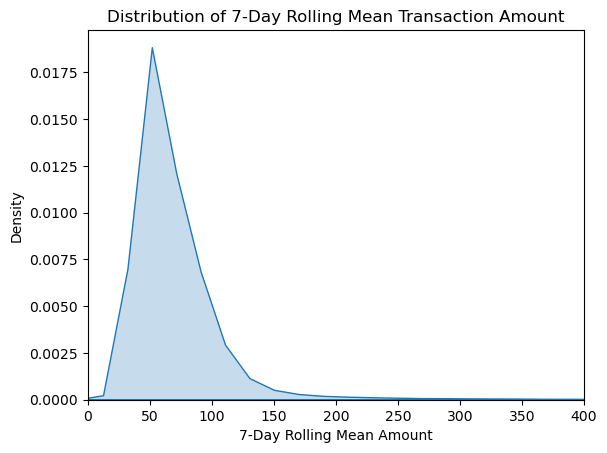

In [24]:
#removing all records with state DE
train_df = train_df[train_df['state']!='DE']

train_df = train_df.sort_values(['cc_num', 'trans_date_trans_time'])
test_df = test_df.sort_values(['cc_num', 'trans_date_trans_time'])

# Create a helper function
def calc_rolling_mean(x):
    return (
        x.set_index('trans_date_trans_time')
         .rolling('7D')['amt']
         .mean()
         .reset_index(drop=False)
    )

# Apply and merge back
train_df_rolled = train_df.groupby('cc_num', group_keys=False).apply(calc_rolling_mean)
train_df['rolling_mean_amt_7d'] = train_df_rolled['amt'].values

test_df_rolled = test_df.groupby('cc_num', group_keys=False).apply(calc_rolling_mean)
test_df['rolling_mean_amt_7d'] = test_df_rolled['amt'].values



def calc_30rolling_mean(x):
    return (
        x.set_index('trans_date_trans_time')
         .rolling('30D')['amt']
         .mean()
         .reset_index(drop=False)
    )

# Apply and merge back
train_df_rolled = train_df.groupby('cc_num', group_keys=False).apply(calc_30rolling_mean)
train_df['rolling_mean_amt_30d'] = train_df_rolled['amt'].values

test_df_rolled = test_df.groupby('cc_num', group_keys=False).apply(calc_30rolling_mean)
test_df['rolling_mean_amt_30d'] = test_df_rolled['amt'].values


# dfhead = df[['trans_date_trans_time', 'cc_num', 'amt', 'rolling_mean_amt_7d', 'rolling_mean_amt_30d']].head(2000)


sns.kdeplot(train_df['rolling_mean_amt_7d'].dropna(), fill=True)
plt.title('Distribution of 7-Day Rolling Mean Transaction Amount')
plt.xlabel('7-Day Rolling Mean Amount')
plt.ylabel('Density')
plt.xlim(0, 400)
plt.show()

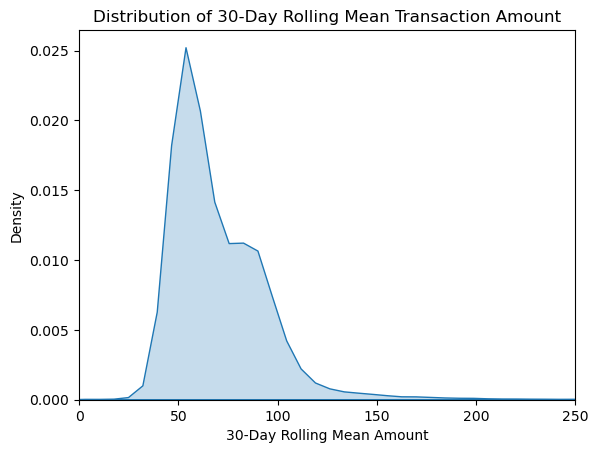

In [25]:
sns.kdeplot(train_df['rolling_mean_amt_30d'].dropna(), fill=True)
plt.title('Distribution of 30-Day Rolling Mean Transaction Amount')
plt.xlabel('30-Day Rolling Mean Amount')
plt.ylabel('Density')
plt.xlim(0, 250)
plt.show()

* The rolling mean distribution shows that most users maintain average spend in the 50 to 100 range, with a few high-value outliers.

* These features are critical for downstream anomaly detection and fraud risk analysis.

# User-Level Feature Aggregation

### We then engineer user-level features like:
*	Age, transaction duration and frequency, standard deviation between transaction days

*	Total amount spent, fraud amount and mean fraud amount

*	Count of unique merchants and categories interacted with

*	Ratios of fraud merchants/categories to total (as proxies for exposure)

*	Region bucketed from U.S. state (Midwest, West, South, etc.)

In [26]:






test_df_fraud

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,unix_time,merch_lat,merch_long,is_fraud,txn_distance_km,txn_distance_mi,dayofweek,dayofmonth,timeofday,month
1685,2020-06-21 22:06:39,3560725013359375,fraud_Hamill-D'Amore,health_fitness,24.84,Brooke,Smith,F,63542 Luna Brook Apt. 012,Notrees,...,1371852399,32.575873,-102.604290,1,80.649140,50.113037,Sun,21,22,06
1767,2020-06-21 22:32:22,6564459919350820,"fraud_Rodriguez, Yost and Jenkins",misc_net,780.52,Douglas,Willis,M,619 Jeremy Garden Apt. 681,Benton,...,1371853942,42.461127,-91.147148,1,66.097917,41.071329,Sun,21,22,06
1781,2020-06-21 22:37:27,6564459919350820,fraud_Nienow PLC,entertainment,620.33,Douglas,Willis,M,619 Jeremy Garden Apt. 681,Benton,...,1371854247,42.771834,-90.158365,1,28.837509,17.918792,Sun,21,22,06
1784,2020-06-21 22:38:55,4005676619255478,"fraud_Heathcote, Yost and Kertzmann",shopping_net,1077.69,William,Perry,M,458 Phillips Island Apt. 768,Denham Springs,...,1371854335,31.204974,-90.261595,1,103.089027,64.056532,Sun,21,22,06
1857,2020-06-21 23:02:16,3560725013359375,fraud_Hermann and Sons,shopping_pos,842.65,Brooke,Smith,F,63542 Luna Brook Apt. 012,Notrees,...,1371855736,31.315782,-102.736390,1,60.504949,37.596020,Sun,21,23,06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517197,2020-12-22 22:05:48,2242176657877538,"fraud_Willms, Kris and Bergnaum",shopping_pos,1041.51,Travis,Daniel,M,1327 Rose Causeway Apt. 610,Senatobia,...,1387749948,34.573471,-89.911011,1,6.945705,4.315860,Tue,22,22,12
517274,2020-12-22 22:18:07,2242176657877538,fraud_Kuhn LLC,shopping_pos,868.09,Travis,Daniel,M,1327 Rose Causeway Apt. 610,Senatobia,...,1387750687,34.091227,-90.390612,1,75.956505,47.197170,Tue,22,22,12
517341,2020-12-22 22:31:48,2242176657877538,"fraud_Mosciski, Ziemann and Farrell",shopping_net,1039.42,Travis,Daniel,M,1327 Rose Causeway Apt. 610,Senatobia,...,1387751508,34.628434,-90.284780,1,36.534673,22.701586,Tue,22,22,12
517529,2020-12-22 23:06:03,2242176657877538,fraud_Bauch-Raynor,grocery_pos,289.27,Travis,Daniel,M,1327 Rose Causeway Apt. 610,Senatobia,...,1387753563,34.746063,-90.401093,1,48.808449,30.328155,Tue,22,23,12


In [27]:
train_df['dob'] = pd.to_datetime(train_df['dob'])
test_df['dob'] = pd.to_datetime(test_df['dob'])

train_df['age'] = round(((train_df['trans_date_trans_time']-train_df['dob']).dt.days)/365, 0)
test_df['age'] = round(((test_df['trans_date_trans_time']-test_df['dob']).dt.days)/365, 0)

train_df['firsttrasaction'] = train_df.groupby('cc_num')['trans_date_trans_time'].transform('min')
test_df['firsttrasaction'] = test_df.groupby('cc_num')['trans_date_trans_time'].transform('min')

train_df['lasttrasaction'] = train_df.groupby('cc_num')['trans_date_trans_time'].transform('max')
test_df['lasttrasaction'] = test_df.groupby('cc_num')['trans_date_trans_time'].transform('max')

train_df['txn_days'] = round((train_df['lasttrasaction']-train_df['firsttrasaction']).dt.days, 0)
test_df['txn_days'] = round((test_df['lasttrasaction']-test_df['firsttrasaction']).dt.days, 0)

train_df['trans_date'] = train_df['trans_date_trans_time'].dt.date
train_df['trans_date'] = pd.to_datetime(train_df['trans_date'])

test_df['trans_date'] = test_df['trans_date_trans_time'].dt.date
test_df['trans_date'] = pd.to_datetime(test_df['trans_date'])

train_df = train_df.sort_values(['cc_num', 'trans_date_trans_time'])
test_df = test_df.sort_values(['cc_num', 'trans_date_trans_time'])

train_df['daysdiff'] = train_df.groupby('cc_num')['trans_date'].diff().dt.days
test_df['daysdiff'] = test_df.groupby('cc_num')['trans_date'].diff().dt.days


# 	1.	Preprocess:
# 	•	age = 2020 - birth year from dob
# 	•	first_txn / last_txn = min/max date per cc_num
# 	•	txn_days = last - first txn date
# 	•	txn_std_gap_days = std of time gaps between txns

# 	2.	Aggregations (per cc_num):
# 	•	avg_txn_amt, total_amt, weekly_avg_amt, monthly_avg_amt
# 	•	txn_count, fraud_count, legit_count
# 	•	unique_merchants, unique_categories
# 	•	avg_txn_distance_km, avg_txn_distance_mi
# 	•	avg_rolling_7d, avg_rolling_30d

# 	3.	One-hot encode:
# 	•	gender, region bucket from state
# 	4.	Groupby + agg on cc_num


train_df['merchant'] = train_df['merchant'].str.replace('fraud_', '')
test_df['merchant'] = test_df['merchant'].str.replace('fraud_', '')
df_fraud['merchant'] = df_fraud['merchant'].str.replace('fraud_', '') # training data
test_df_fraud['merchant'] = test_df_fraud['merchant'].str.replace('fraud_', '') # test data


train_df = train_df.merge(train_df[['cc_num', 'merchant']].drop_duplicates().groupby('cc_num').size().reset_index(name='uniquemerchants'), on='cc_num', how='left')
test_df = test_df.merge(test_df[['cc_num', 'merchant']].drop_duplicates().groupby('cc_num').size().reset_index(name='uniquemerchants'), on='cc_num', how='left')


train_df = train_df.merge(train_df[['cc_num', 'category']].drop_duplicates().groupby('cc_num').size().reset_index(name='uniquecategories'), on='cc_num', how='left')
test_df = test_df.merge(test_df[['cc_num', 'category']].drop_duplicates().groupby('cc_num').size().reset_index(name='uniquecategories'), on='cc_num', how='left')


train_df = train_df.merge(df_fraud[['cc_num', 'category']].drop_duplicates().groupby('cc_num').size().reset_index(name='uniquefraudcategories'), on='cc_num', how='left')
test_df = test_df.merge(test_df_fraud[['cc_num', 'category']].drop_duplicates().groupby('cc_num').size().reset_index(name='uniquefraudcategories'), on='cc_num', how='left')


train_df = train_df.merge(df_fraud[['cc_num', 'merchant']].drop_duplicates().groupby('cc_num').size().reset_index(name='uniquefraudmerchant'), on='cc_num', how='left')
test_df = test_df.merge(test_df_fraud[['cc_num', 'merchant']].drop_duplicates().groupby('cc_num').size().reset_index(name='uniquefraudmerchant'), on='cc_num', how='left')



train_df[['uniquefraudcategories', 'uniquefraudmerchant']] = train_df[['uniquefraudcategories', 'uniquefraudmerchant']].fillna(0) 
test_df[['uniquefraudcategories', 'uniquefraudmerchant']] = test_df[['uniquefraudcategories', 'uniquefraudmerchant']].fillna(0) 


train_df['fraudmerchantratio1000'] = (train_df['uniquefraudmerchant']/train_df['uniquemerchants']).astype(float)
test_df['fraudmerchantratio1000'] = (test_df['uniquefraudmerchant']/test_df['uniquemerchants']).astype(float)


train_df['fraudcategoryratio1000'] = train_df['uniquefraudcategories']/train_df['uniquecategories'].astype(float)
test_df['fraudcategoryratio1000'] = test_df['uniquefraudcategories']/test_df['uniquecategories'].astype(float)


train_df['daysdiff'] = train_df['daysdiff'].fillna(0)  
test_df['daysdiff'] = test_df['daysdiff'].fillna(0) 


state_region_map = {
    'CT':'Northeast', 'ME':'Northeast', 'MA':'Northeast', 'NH':'Northeast', 'RI':'Northeast', 'VT':'Northeast',
    'NJ':'Northeast', 'NY':'Northeast', 'PA':'Northeast',
    'IL':'Midwest', 'IN':'Midwest', 'MI':'Midwest', 'OH':'Midwest', 'WI':'Midwest',
    'IA':'Midwest', 'KS':'Midwest', 'MN':'Midwest', 'MO':'Midwest', 'NE':'Midwest', 'ND':'Midwest', 'SD':'Midwest',
    'DE':'South', 'FL':'South', 'GA':'South', 'MD':'South', 'NC':'South', 'SC':'South', 'VA':'South', 'DC':'South', 'WV':'South',
    'AL':'South', 'KY':'South', 'MS':'South', 'TN':'South', 'AR':'South', 'LA':'South', 'OK':'South', 'TX':'South',
    'AZ':'West', 'CO':'West', 'ID':'West', 'MT':'West', 'NV':'West', 'NM':'West', 'UT':'West', 'WY':'West',
    'AK':'West', 'CA':'West', 'HI':'West', 'OR':'West', 'WA':'West'
}

train_df['region'] = train_df['state'].map(state_region_map)
test_df['region'] = test_df['state'].map(state_region_map)

dfhead = train_df[['cc_num','state','region', 'uniquemerchants', 'uniquefraudmerchant','uniquecategories','uniquefraudcategories','fraudmerchantratio1000','fraudcategoryratio1000','merchant','dob', 'trans_date_trans_time', 'age', 'daysdiff']].head(2000)


train_dfgroup = train_df.groupby('cc_num').agg(
    transcount = ('cc_num', 'count'),
    avgtransamt = ('amt', 'mean'),
    tottransamt = ('amt', 'sum'),
    fraudtrans = ('is_fraud', 'sum'),
    totalfraudamt=('amt', lambda x: x[train_df.loc[x.index, 'is_fraud'] == 1].sum()),
    meanfraudamt=('amt', lambda x: x[train_df.loc[x.index, 'is_fraud'] == 1].mean()),
    avgtxn_distance_mi=('txn_distance_mi', 'mean'),
    avgrolling7dayamt = ('rolling_mean_amt_7d', 'mean'),
    avgrolling30dayamt = ('rolling_mean_amt_30d', 'mean'),
    age = ('age', 'first'),
    stddevdaysdiff = ('daysdiff', 'std'),
    gender = ('gender', 'first'),
    fraudmerchantratio1000 = ('fraudmerchantratio1000', 'first'),
    fraudcategoryratio1000 = ('fraudcategoryratio1000', 'first'),
    region = ('region', 'first')
    ).reset_index()



test_dfgroup = test_df.groupby('cc_num').agg(
    transcount = ('cc_num', 'count'),
    avgtransamt = ('amt', 'mean'),
    tottransamt = ('amt', 'sum'),
    fraudtrans = ('is_fraud', 'sum'),
    totalfraudamt=('amt', lambda x: x[test_df.loc[x.index, 'is_fraud'] == 1].sum()),
    meanfraudamt=('amt', lambda x: x[test_df.loc[x.index, 'is_fraud'] == 1].mean()),
    avgtxn_distance_mi=('txn_distance_mi', 'mean'),
    avgrolling7dayamt = ('rolling_mean_amt_7d', 'mean'),
    avgrolling30dayamt = ('rolling_mean_amt_30d', 'mean'),
    age = ('age', 'first'),
    stddevdaysdiff = ('daysdiff', 'std'),
    gender = ('gender', 'first'),
    fraudmerchantratio1000 = ('fraudmerchantratio1000', 'first'),
    fraudcategoryratio1000 = ('fraudcategoryratio1000', 'first'),
    region = ('region', 'first')
    ).reset_index()


train_dfgroup = train_dfgroup.fillna(0)
test_dfgroup = test_dfgroup.fillna(0)

train_dfgroup

E:\spark_temp\ipykernel_12416\2452360764.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fraud['merchant'] = df_fraud['merchant'].str.replace('fraud_', '') # training data
E:\spark_temp\ipykernel_12416\2452360764.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df_fraud['merchant'] = test_df_fraud['merchant'].str.replace('fraud_', '') # test data


,cc_num,transcount,avgtransamt,tottransamt,fraudtrans,totalfraudamt,meanfraudamt,avgtxn_distance_mi,avgrolling7dayamt,avgrolling30dayamt,age,stddevdaysdiff,gender,fraudmerchantratio1000,fraudcategoryratio1000,region
0,60416207185,1518,56.023366,85043.47,9,1899.73,211.081111,45.859664,55.859211,55.382938,33.0,0.536741,F,0.015652,0.500000,West
1,60422928733,1531,69.000784,105640.20,12,7500.18,625.015000,49.195602,68.983561,68.751021,77.0,0.551911,M,0.019031,0.357143,South
2,60423098130,510,115.046333,58673.63,10,4598.08,459.808000,48.018767,107.504335,96.755852,60.0,1.199029,M,0.026627,0.500000,South
3,60427851591,528,111.987898,59129.61,14,9645.79,688.985000,46.738806,108.590206,107.581412,43.0,1.203180,M,0.039106,0.285714,South
4,60487002085,496,50.726028,25160.11,0,0.00,0.000000,49.439673,51.003046,49.791371,46.0,1.177680,M,0.000000,0.000000,South
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,4958589671582726883,1476,66.377839,97973.69,0,0.00,0.000000,47.816768,65.406018,65.314114,68.0,0.543453,M,0.000000,0.000000,South
978,4973530368125489546,1040,78.373288,81508.22,10,5371.07,537.107000,49.198669,77.957604,76.456238,53.0,0.720779,F,0.019608,0.428571,South
979,4980323467523543940,532,74.436429,39600.18,10,7208.15,720.815000,45.444413,69.993562,69.539820,71.0,1.311246,M,0.027322,0.285714,Northeast
980,4989847570577635369,1007,87.582542,88195.62,0,0.00,0.000000,48.142537,87.621652,88.934036,25.0,0.705489,F,0.000000,0.000000,South


In [28]:
test_dfgroup

,cc_num,transcount,avgtransamt,tottransamt,fraudtrans,totalfraudamt,meanfraudamt,avgtxn_distance_mi,avgrolling7dayamt,avgrolling30dayamt,age,stddevdaysdiff,gender,fraudmerchantratio1000,fraudcategoryratio1000,region
0,60416207185,678,66.499484,45086.65,0,0.00,0.000000,45.248842,66.887186,66.642476,34.0,0.477036,F,0.000000,0.000000,West
1,60422928733,669,57.433109,38422.75,0,0.00,0.000000,48.899760,56.375997,56.218800,78.0,0.475951,M,0.000000,0.000000,South
2,60423098130,228,54.613684,12451.92,0,0.00,0.000000,49.154245,54.903634,54.281716,62.0,1.045898,M,0.000000,0.000000,South
3,60427851591,215,96.435535,20733.64,0,0.00,0.000000,47.839654,96.651569,97.348613,44.0,1.003082,M,0.000000,0.000000,South
4,60487002085,239,91.845732,21951.13,8,5610.80,701.350000,49.302971,75.101470,86.277179,48.0,0.968292,M,0.041667,0.285714,South
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
919,4958589671582726883,715,68.914378,49273.78,7,5638.03,805.432857,47.400314,69.621903,68.712156,70.0,0.476980,M,0.017157,0.285714,South
920,4973530368125489546,427,69.495222,29674.46,0,0.00,0.000000,48.340021,67.347787,63.347125,55.0,0.631278,F,0.000000,0.000000,South
921,4980323467523543940,204,60.990196,12442.00,0,0.00,0.000000,43.416116,59.194423,55.915308,73.0,0.958259,M,0.000000,0.000000,Northeast
922,4989847570577635369,464,104.785625,48620.53,15,4234.21,282.280667,47.211438,105.833908,103.451360,26.0,0.677822,F,0.041916,0.642857,South


In [29]:
# one hot encoding and data scaling

train_dfgroup = pd.get_dummies(train_dfgroup, columns=['gender', 'region'], drop_first=True)
train_dfgroup = train_dfgroup.astype({col: 'int' for col in train_dfgroup.select_dtypes('bool').columns})

test_dfgroup = pd.get_dummies(test_dfgroup, columns=['gender', 'region'], drop_first=True)
test_dfgroup = test_dfgroup.astype({col: 'int' for col in test_dfgroup.select_dtypes('bool').columns})

train_dfgroup_cluster = train_dfgroup.drop('cc_num', axis=1)
test_dfgroup_cluster = test_dfgroup.drop('cc_num', axis=1)

scaler = StandardScaler()

train_dfgroup_scaled = pd.DataFrame(scaler.fit_transform(train_dfgroup_cluster), columns=train_dfgroup_cluster.columns, index=train_dfgroup_cluster.index)
test_dfgroup_scaled = pd.DataFrame(scaler.fit_transform(test_dfgroup_cluster), columns=test_dfgroup_cluster.columns, index=test_dfgroup_cluster.index)

In [30]:
train_dfgroup_scaled.columns

Index(['transcount', 'avgtransamt', 'tottransamt', 'fraudtrans',
       'totalfraudamt', 'meanfraudamt', 'avgtxn_distance_mi',
       'avgrolling7dayamt', 'avgrolling30dayamt', 'age', 'stddevdaysdiff',
       'fraudmerchantratio1000', 'fraudcategoryratio1000', 'gender_M',
       'region_Northeast', 'region_South', 'region_West'],
      dtype='object')

In [31]:
test_dfgroup_scaled.columns

Index(['transcount', 'avgtransamt', 'tottransamt', 'fraudtrans',
       'totalfraudamt', 'meanfraudamt', 'avgtxn_distance_mi',
       'avgrolling7dayamt', 'avgrolling30dayamt', 'age', 'stddevdaysdiff',
       'fraudmerchantratio1000', 'fraudcategoryratio1000', 'gender_M',
       'region_Northeast', 'region_South', 'region_West'],
      dtype='object')

# Data Preprocessing

### Before clustering, we:
* One-hot encoded categorical variables (gender, region)

* Scaled all numerical features using StandardScaler

* Dropped ID fields like cc_num to avoid leakage

C:\Users\Tejas Patil\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Tejas Patil\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Tejas Patil\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Tejas Patil\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows 

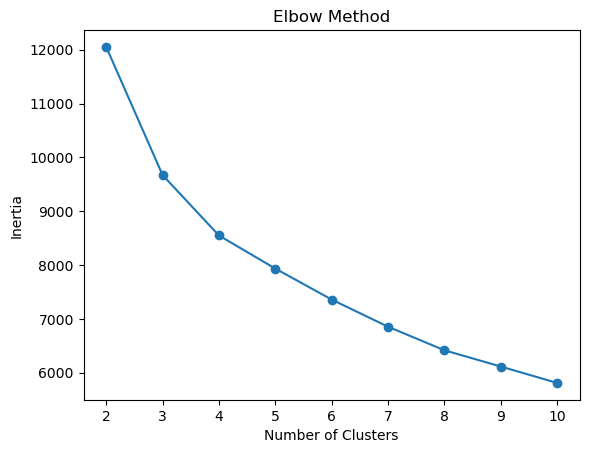

C:\Users\Tejas Patil\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Tejas Patil\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Silhouette Score: 0.19


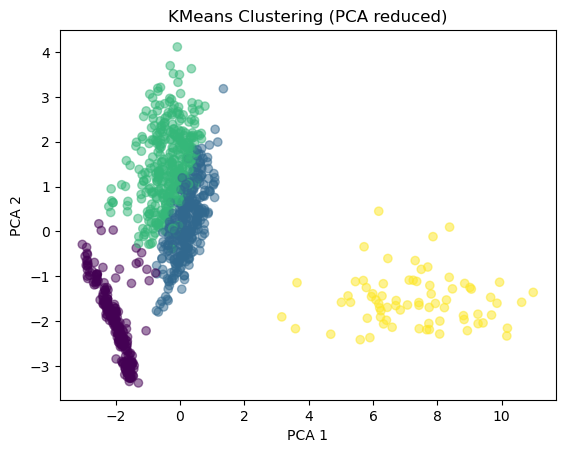

In [32]:
# Elbow plot
inertia = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(train_dfgroup_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Final KMeans
kmeans = KMeans(n_clusters=4, random_state=42)  
train_dfgroup_cluster['cluster'] = kmeans.fit_predict(train_dfgroup_scaled)

# Silhouette score
score = silhouette_score(train_dfgroup_scaled, train_dfgroup_cluster['cluster'])
print(f'Silhouette Score: {score:.2f}')

# Optional 2D visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(train_dfgroup_scaled)

plt.scatter(pca_result[:, 0], pca_result[:, 1], c=train_dfgroup_cluster['cluster'], cmap='viridis', alpha=0.5)
plt.title('KMeans Clustering (PCA reduced)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [33]:
train_dfgroup_cluster['cluster'] = kmeans.labels_
cluster_summary = train_dfgroup_cluster.groupby('cluster').mean()

In [34]:
cluster_summary

,transcount,avgtransamt,tottransamt,fraudtrans,totalfraudamt,meanfraudamt,avgtxn_distance_mi,avgrolling7dayamt,avgrolling30dayamt,age,stddevdaysdiff,fraudmerchantratio1000,fraudcategoryratio1000,gender_M,region_Northeast,region_South,region_West
cluster,,,,,,,,,,,,,,,,,
0,1472.402542,68.536221,100590.619280,0.228814,37.615212,10.643024,47.273906,68.578051,68.517748,47.288136,0.703912,0.000403,0.013015,0.449153,0.177966,0.368644,0.156780
1,755.738710,72.905821,54496.199774,9.764516,5306.257806,542.888689,47.261252,72.049947,72.467847,52.400000,0.982675,0.023476,0.377419,0.554839,0.180645,0.345161,0.158065
2,1972.839779,70.739906,138527.071022,10.176796,5226.106050,515.148871,47.314040,70.669461,70.705813,44.127072,0.496144,0.016435,0.407261,0.469613,0.201657,0.389503,0.135359
3,9.891892,597.433302,5916.090135,9.891892,5916.090135,597.433302,47.444316,516.367727,516.367727,59.445946,0.318174,1.000000,1.000000,0.513514,0.216216,0.405405,0.162162


# Interpretation of Clusters

### Based on the cluster means:
* Cluster 0: Likely low-risk, high-volume spenders with low fraud ratios.
  
* Cluster 1: Mixed behavior — moderate spend and some fraud exposure.

* Cluster 2: Possibly heavy spenders, but with tight control and low fraud.

* Cluster 3: Very high fraud amount or all fraud transactions → high-risk profiles.

# Transaction-Level Fraud Prediction

In this section, we build a binary classification model to predict whether a given credit card transaction is fraudulent. We use the is_fraud column as our target and engineer a variety of contextual, behavioral, temporal and user-level features to enhance model accuracy.

## Feature Engineering

We enrich each transaction with a wide range of informative features:

* User-level history: total transactions, total/fraud spend, avg transaction amount, standard deviation of transaction gaps and rolling averages
  
* Transaction behavior: amt, log(amt), is_high_value_txn, txn_distance_mi, days_since_last_txn and merchant_fraud_rate

* Time-based features: hourofday, dayofweek, dayofmonth, season, isweekend, isnight

* Cyclical encoding: sine/cosine transformation for hour and day to preserve cyclic patterns

We also include one-hot encoded categorical features: merchant category, gender, region, season and day of week.

In [35]:
train_df_ml = train_df[['trans_date_trans_time', 'cc_num', 'merchant','category', 'amt',
       'gender', 'city_pop', 'trans_num', 'is_fraud',
       'txn_distance_mi', 'rolling_mean_amt_7d', 'rolling_mean_amt_30d', 'age',
       'trans_date',
       'daysdiff',
       'fraudmerchantratio1000', 'fraudcategoryratio1000', 'region']]

test_df_ml = test_df[['trans_date_trans_time', 'cc_num', 'merchant','category', 'amt',
       'gender', 'city_pop', 'trans_num', 'is_fraud',
       'txn_distance_mi', 'rolling_mean_amt_7d', 'rolling_mean_amt_30d', 'age',
       'trans_date',
       'daysdiff',
       'fraudmerchantratio1000', 'fraudcategoryratio1000', 'region']]


train_dfgroup = train_dfgroup[['cc_num', 'transcount', 'avgtransamt', 'tottransamt', 'fraudtrans',
       'totalfraudamt', 'meanfraudamt', 'stddevdaysdiff']]

test_dfgroup = test_dfgroup[['cc_num', 'transcount', 'avgtransamt', 'tottransamt', 'fraudtrans',
       'totalfraudamt', 'meanfraudamt', 'stddevdaysdiff']]



train_df_ml = train_df_ml.merge(train_dfgroup, on='cc_num', how='left')
test_df_ml = test_df_ml.merge(test_dfgroup, on='cc_num', how='left')


train_df_ml['hourofday'] = train_df_ml['trans_date_trans_time'].dt.strftime('%H').astype(int)
train_df_ml['dayofweek'] = train_df_ml['trans_date'].dt.strftime('%a')
train_df_ml['dayofmonth'] = train_df_ml['trans_date'].dt.strftime('%d').astype(int)

test_df_ml['hourofday'] = test_df_ml['trans_date_trans_time'].dt.strftime('%H').astype(int)
test_df_ml['dayofweek'] = test_df_ml['trans_date'].dt.strftime('%a')
test_df_ml['dayofmonth'] = test_df_ml['trans_date'].dt.strftime('%d').astype(int)


train_df_ml['isweekend'] = np.where(train_df_ml['dayofweek'].isin(['Sat','Sun']), 1, 0)
test_df_ml['isweekend'] = np.where(test_df_ml['dayofweek'].isin(['Sat','Sun']), 1, 0)


train_df_ml['isnight'] = np.where(
        (train_df_ml['hourofday'].astype(int) >= 22) | (train_df_ml['hourofday'].astype(int) <= 5), 1, 0
    )
test_df_ml['isnight'] = np.where(
        (test_df_ml['hourofday'].astype(int) >= 22) | (test_df_ml['hourofday'].astype(int) <= 5), 1, 0
    )



train_df_ml['logamt'] = np.log1p(train_df_ml['amt'])
test_df_ml['logamt'] = np.log1p(test_df_ml['amt'])


train_df_ml['merchant_fraud_rate'] = train_df_ml.groupby('merchant')['is_fraud'].transform('mean')
test_df_ml['merchant_fraud_rate'] = test_df_ml.groupby('merchant')['is_fraud'].transform('mean')


train_threshold = train_df_ml['amt'].quantile(0.9)
train_df_ml['is_high_value_txn'] = (train_df_ml['amt'] > train_threshold).astype(int)

test_threshold = test_df_ml['amt'].quantile(0.9)
test_df_ml['is_high_value_txn'] = (test_df_ml['amt'] > test_threshold).astype(int)

# Days since last txn per cc_num
train_df_ml = train_df_ml.sort_values(['cc_num', 'trans_date_trans_time'])
train_df_ml['days_since_last_txn'] = train_df_ml.groupby('cc_num')['trans_date_trans_time'].diff().dt.days
train_df_ml['days_since_last_txn'] = train_df_ml['days_since_last_txn'].fillna(0)

test_df_ml = test_df_ml.sort_values(['cc_num', 'trans_date_trans_time'])
test_df_ml['days_since_last_txn'] = test_df_ml.groupby('cc_num')['trans_date_trans_time'].diff().dt.days
test_df_ml['days_since_last_txn'] = test_df_ml['days_since_last_txn'].fillna(0)


def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

train_df_ml['season'] = train_df_ml['trans_date_trans_time'].dt.month.map(get_season)
test_df_ml['season'] = test_df_ml['trans_date_trans_time'].dt.month.map(get_season)


train_df_ml['hour_sin'] = np.sin(2 * np.pi * train_df_ml['hourofday'].astype(int) / 24)
test_df_ml['hour_sin'] = np.sin(2 * np.pi * test_df_ml['hourofday'].astype(int) / 24)


train_df_ml['hour_cos'] = np.cos(2 * np.pi * train_df_ml['hourofday'].astype(int) / 24)
test_df_ml['hour_cos'] = np.cos(2 * np.pi * test_df_ml['hourofday'].astype(int) / 24)


train_df_ml['day_sin'] = np.sin(2 * np.pi * train_df_ml['dayofmonth'].astype(int) / 31)
test_df_ml['day_sin'] = np.sin(2 * np.pi * test_df_ml['dayofmonth'].astype(int) / 31)


train_df_ml['day_cos'] = np.cos(2 * np.pi * train_df_ml['dayofmonth'].astype(int) / 31)
test_df_ml['day_cos'] = np.cos(2 * np.pi * test_df_ml['dayofmonth'].astype(int) / 31)


train_df_ml = train_df_ml[['category', 'amt',
       'gender', 'city_pop', 'trans_num', 'is_fraud', 'txn_distance_mi',
       'rolling_mean_amt_7d', 'rolling_mean_amt_30d', 'age',
       'daysdiff', 'fraudmerchantratio1000', 'fraudcategoryratio1000',
       'region', 'transcount', 'avgtransamt', 'tottransamt', 'fraudtrans',
       'totalfraudamt', 'meanfraudamt', 'stddevdaysdiff', 'hourofday',
       'dayofweek', 'dayofmonth', 'isweekend', 'isnight', 'logamt',
       'merchant_fraud_rate', 'is_high_value_txn', 'days_since_last_txn',
       'season','hour_sin', 'hour_cos', 'day_sin', 'day_cos']]

test_df_ml = test_df_ml[['category', 'amt',
       'gender', 'city_pop', 'trans_num', 'is_fraud', 'txn_distance_mi',
       'rolling_mean_amt_7d', 'rolling_mean_amt_30d', 'age',
       'daysdiff', 'fraudmerchantratio1000', 'fraudcategoryratio1000',
       'region', 'transcount', 'avgtransamt', 'tottransamt', 'fraudtrans',
       'totalfraudamt', 'meanfraudamt', 'stddevdaysdiff', 'hourofday',
       'dayofweek', 'dayofmonth', 'isweekend', 'isnight', 'logamt',
       'merchant_fraud_rate', 'is_high_value_txn', 'days_since_last_txn',
       'season','hour_sin', 'hour_cos', 'day_sin', 'day_cos']]


train_df_ml = pd.get_dummies(train_df_ml, columns=['category', 'gender', 'region', 'dayofweek', 'season'], drop_first=True)
train_df_ml = train_df_ml.astype({col: 'int' for col in train_df_ml.select_dtypes('bool').columns})

test_df_ml = pd.get_dummies(test_df_ml, columns=['category', 'gender', 'region', 'dayofweek', 'season'], drop_first=True)
test_df_ml = test_df_ml.astype({col: 'int' for col in test_df_ml.select_dtypes('bool').columns})

# Align columns
test_df_ml = test_df_ml.reindex(columns=train_df_ml.columns, fill_value=0)

In [36]:
train_df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296666 entries, 0 to 1296665
Data columns (total 56 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   amt                      1296666 non-null  float64
 1   city_pop                 1296666 non-null  int64  
 2   trans_num                1296666 non-null  object 
 3   is_fraud                 1296666 non-null  int64  
 4   txn_distance_mi          1296666 non-null  float64
 5   rolling_mean_amt_7d      1296666 non-null  float64
 6   rolling_mean_amt_30d     1296666 non-null  float64
 7   age                      1296666 non-null  float64
 8   daysdiff                 1296666 non-null  float64
 9   fraudmerchantratio1000   1296666 non-null  float64
 10  fraudcategoryratio1000   1296666 non-null  float64
 11  transcount               1296666 non-null  int64  
 12  avgtransamt              1296666 non-null  float64
 13  tottransamt              1296666 non-null 

In [37]:
test_df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 555719 entries, 0 to 555718
Data columns (total 56 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   amt                      555719 non-null  float64
 1   city_pop                 555719 non-null  int64  
 2   trans_num                555719 non-null  object 
 3   is_fraud                 555719 non-null  int64  
 4   txn_distance_mi          555719 non-null  float64
 5   rolling_mean_amt_7d      555719 non-null  float64
 6   rolling_mean_amt_30d     555719 non-null  float64
 7   age                      555719 non-null  float64
 8   daysdiff                 555719 non-null  float64
 9   fraudmerchantratio1000   555719 non-null  float64
 10  fraudcategoryratio1000   555719 non-null  float64
 11  transcount               555719 non-null  int64  
 12  avgtransamt              555719 non-null  float64
 13  tottransamt              555719 non-null  float64
 14  frau

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score


# Model Training and Evaluation

## We trained three different classification models on the processed dataset:
* Logistic Regression
  
* Random Forest

* XGBoost Classifier

All models were trained on a 70/30 stratified train-test split and evaluated using Accuracy, F1 Score and AUC (Area Under ROC Curve).

In [39]:
# Drop ID column
train_df_ml = train_df_ml.drop(columns=['trans_num'])
test_df_ml = test_df_ml.drop(columns=['trans_num'])

In [40]:
# Align columns
# test_df_ml = test_df_ml.reindex(columns=train_df_ml.columns, fill_value=0)

In [41]:
# Define X and y
X_train = train_df_ml.drop(columns=['is_fraud'])
y_train = train_df_ml['is_fraud']

X_test = test_df_ml.drop(columns=['is_fraud'])
y_test = test_df_ml['is_fraud']

In [42]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296666 entries, 0 to 1296665
Data columns (total 54 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   amt                      1296666 non-null  float64
 1   city_pop                 1296666 non-null  int64  
 2   txn_distance_mi          1296666 non-null  float64
 3   rolling_mean_amt_7d      1296666 non-null  float64
 4   rolling_mean_amt_30d     1296666 non-null  float64
 5   age                      1296666 non-null  float64
 6   daysdiff                 1296666 non-null  float64
 7   fraudmerchantratio1000   1296666 non-null  float64
 8   fraudcategoryratio1000   1296666 non-null  float64
 9   transcount               1296666 non-null  int64  
 10  avgtransamt              1296666 non-null  float64
 11  tottransamt              1296666 non-null  float64
 12  fraudtrans               1296666 non-null  int64  
 13  totalfraudamt            1296666 non-null 

In [43]:
y_train.info()

<class 'pandas.core.series.Series'>
Int64Index: 1296666 entries, 0 to 1296665
Series name: is_fraud
Non-Null Count    Dtype
--------------    -----
1296666 non-null  int64
dtypes: int64(1)
memory usage: 19.8 MB


In [44]:
#X_train['hourofday'] = X_train['hourofday'].astype(int)
#X_test['hourofday']  = X_test['hourofday'].astype(int)

#X_train['dayofmonth'] = X_train['dayofmonth'].astype(int)
#X_test['dayofmonth']  = X_test['dayofmonth'].astype(int)


In [45]:


# Fit on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the SAME scaler
X_test_scaled = scaler.transform(X_test)


In [46]:
# Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, stratify=y, test_size=0.3, random_state=42)

# Models
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [47]:
#from sklearn.metrics import recall_score

In [48]:
# Evaluation
for name, model in models.items():
    if name == 'LogisticRegression':
        model.fit(X_train_scaled, y_train)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]

    # Choose threshold
    y_pred = (y_prob >= 0.5).astype(int)

    auc  = roc_auc_score(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)

    print(f"{name} → AUC: {auc:.4f}, Accuracy: {acc:.4f}, F1: {f1:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}")


LogisticRegression → AUC: 0.9868, Accuracy: 0.9976, F1: 0.6025, Precision: 0.8641, Recall: 0.4625
RandomForest → AUC: 0.9772, Accuracy: 0.9991, F1: 0.8650, Precision: 0.9760, Recall: 0.7767
XGBoost → AUC: 0.9996, Accuracy: 0.9993, F1: 0.9059, Precision: 0.9603, Recall: 0.8573


In [49]:
print(X_train.dtypes[X_train.dtypes == 'object'])


Series([], dtype: object)


# Observations
*Impact of Class Imbalance*
1. Although all models achieved very high accuracy (≥ 99%), this is misleading due to the heavy imbalance (fraud cases are rare).
2. Metrics like F1-Score, Recall and AUC-ROC provide a much clearer picture of real-world performance.


*Model Comparison*
1. XGBoost performed best overall:
Highest AUC (≈ 0.9996), showing it discriminates well between fraud and non-fraud.
Strong Recall (≈ 0.86) and F1-Score (≈ 0.91), meaning it captures most fraud cases while keeping false positives lower.

2. Random Forest also performed strongly:
F1 ≈ 0.87 with reasonable Recall (~ 0.78), but slightly lower than XGBoost.

3. Logistic Regression:
Competitive AUC (≈ 0.9868), indicating it ranks risky transactions fairly well.
However, lower F1 (≈ 0.60) and Recall (≈ 0.46) at default threshold, meaning it misses many fraud cases.



*Threshold Sensitivity*

Logistic Regression’s good AUC but low Recall highlights the importance of adjusting the decision threshold for imbalanced problems.
Further tuning of the threshold (or using PR-AUC to select it) could boost fraud capture rates.

*Business Implication*
For fraud detection, Recall is critical (catch as many frauds as possible) even at the cost of slightly lower precision.
Tree-based models (Random Forest, XGBoost) currently offer the best trade-off for practical deployment..

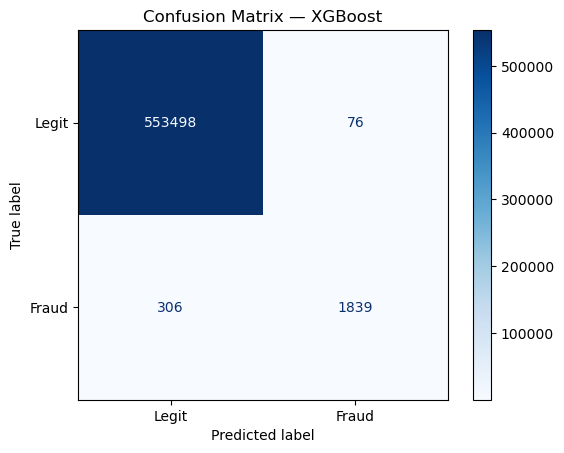

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Example: Using best model (XGBoost here)
model = models['XGBoost']
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — XGBoost')
plt.show()

# Confusion Matrix (XGBoost)

## The confusion matrix gives us a deeper look at how well the model is distinguishing between fraud and legitimate transactions.

* True Positives (Fraud correctly identified): 1,839
  
* False Negatives (Fraud missed): 306

* True Negatives (Legit correctly identified): 5,53,498

* False Positives (Legit marked as fraud): 76

This shows the model performs well even in a highly imbalanced setting, with a very low false positive rate.

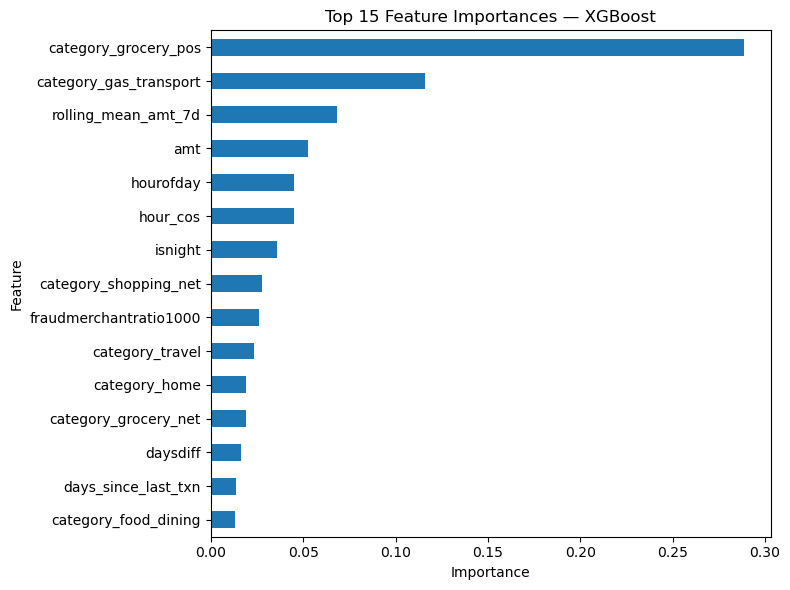

In [51]:
xgb = models['XGBoost']
importances = xgb.feature_importances_

feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 15
importance_df.head(15).plot(kind='barh', x='Feature', y='Importance', figsize=(8,6), legend=False)
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances — XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Feature Importance

## To interpret the model, we visualized the top 15 most impactful features as measured by XGBoost’s feature gain metric:
    
## The most influential features were:
* category_grocery_pos and category_gas_transport — indicating spending context plays a strong role in fraud detection.
  
* rolling_mean_amt_7d and amt — recent and current transaction amounts are critical signals.

* hour-related features — time of day and night activity patterns contribute significantly.

In [52]:
from sklearn.metrics import precision_recall_curve

y_probs = model.predict_proba(X_test)[:, 1]
prec, recall, thresholds = precision_recall_curve(y_test, y_probs)

f1_scores = 2 * (prec * recall) / (prec + recall)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Best Threshold: {best_threshold:.2f}")
print(f"Max F1 Score: {f1_scores[best_idx]:.4f}")

# Apply new threshold
y_pred_tuned = (y_probs >= best_threshold).astype(int)

# Recalculate metrics
acc = accuracy_score(y_test, y_pred_tuned)
f1 = f1_score(y_test, y_pred_tuned)
auc = roc_auc_score(y_test, y_probs)

print(f'Tuned — Accuracy: {acc:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}')

Best Threshold: 0.41
Max F1 Score: 0.9102
Tuned — Accuracy: 0.9993, F1: 0.9102, AUC: 0.9996


# Threshold Tuning for Maximum F1 Score

## By default, classification models use a 0.5 threshold for binary outcomes. But with imbalanced data like fraud detection, F1-score optimization is often more meaningful.

### We evaluated performance across multiple thresholds and found:
* Best Threshold: 0.41
  
* Max F1 Score: 0.9102

* Tuned Accuracy: 0.9993

* Tuned AUC: 0.9996

Threshold tuning helped strike a better balance between precision and recall, reducing false negatives while keeping false positives extremely low — a critical factor for financial fraud detection systems.


# Conclusion

## In this comprehensive fraud detection project, we journeyed through every critical stage of a real-world data science pipeline:

### Exploratory Data Analysis (EDA)

* Explored patterns across state, category, city and time-based variables to understand transaction behaviors.
* Analyzed fraud proportions across demographic segments, especially highlighting spatial and temporal fraud hotspots.
* Created rolling statistics, such as 7-day and 30-day transaction averages, to capture user spending behavior.

### User-Level Clustering

* Engineered user-level features like unique merchants, fraud ratios and transaction activity patterns.
* Applied KMeans clustering to segment users into behavioral groups.
* Identified clusters with distinct characteristics — e.g., high-value, high-frequency users or sporadic low-spenders — laying groundwork for personalization or anomaly detection.


### Transaction-Level Feature Engineering

#### Built detailed transaction-level signals, including:
* Time of transaction (hour, day, weekend/night indicators)
* Merchant fraud rate, high-value tags, rolling amounts
* One-hot encoding of category, season and region
* Combined user-level aggregates with individual transaction behavior for richer modeling.

### Model Building & Evaluation
* Trained Logistic Regression, Random Forest and XGBoost classifiers.
* XGBoost outperformed all models, achieving:
* F1 Score: 0.9059
* AUC: 0.9996
* Accuracy: 0.9993
* Used confusion matrix and feature importance to interpret predictions and key fraud indicators.



#  Final Thoughts

From raw transactional data to an interpretable, production-ready fraud prediction model, this project demonstrates the full lifecycle of applied machine learning. The combination of temporal features, domain-specific aggregations and careful evaluation makes this pipeline powerful, scalable and adaptable to real-world fraud scenarios.